<a href="https://colab.research.google.com/github/yasminn89/tencent-mini-prep/blob/main/experiment2_prompt_eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 实验2：用 LLM API + Prompt Engineering 构建文本质量评估器

**腾讯 Mini 项目3 — 性能工程 Skill 评估专项**

---

## 📋 实验目标

掌握三种核心 Prompt Engineering 技巧，并通过对比实验量化其效果：

| 技巧 | 说明 |
|------|------|
| **System Prompt** | 设定角色身份与任务框架 |
| **Few-shot** | 通过示例引导输出格式 |
| **Chain-of-Thought (CoT)** | 引导模型逐步推理 |

**评估维度**：对 AI 生成的代码注释质量打分（准确性 / 完整性 / 可读性）

---

## 🗂 实验流程

```
Step 1: 安装依赖 & 配置 API
Step 2: 准备测试数据集（代码注释样本）
Step 3: 设计 System Prompt
Step 4: 构造 Few-shot 示例
Step 5: 引入 CoT 推理链
Step 6: 结构化输出（JSON）
Step 7: 多 Prompt 策略对比实验
Step 8: 结果可视化 & 分析
```

## Step 1：安装依赖 & 配置 DeepSeek API

> ⚠️ **操作前请先完成**：
> 1. 访问 [platform.deepseek.com](https://platform.deepseek.com) 注册账号
> 2. 在「API Keys」页面创建新的 API Key
> 3. 将 Key 填入下方 `DEEPSEEK_API_KEY`

In [1]:
# ============================================================
# 1.1 安装所需库
# ============================================================
!pip install openai pandas matplotlib seaborn tabulate -q

print('✅ 依赖安装完成')

✅ 依赖安装完成


In [4]:
# ============================================================
# 1.2 配置 API（DeepSeek 兼容 OpenAI SDK，使用相同接口）
# ============================================================
import os
from openai import OpenAI
from google.colab import userdata  # Colab 的安全密钥存储

# ── 方法A（推荐）：在 Colab 左侧「🔑 Secrets」添加 DEEPSEEK_API_KEY ──
try:
    api_key = userdata.get('DEEPSEEK_API_KEY')
    print('✅ 已从 Colab Secrets 读取 API Key')
except Exception:
    # ── 方法B（备用）：直接粘贴，注意不要 commit 到 GitHub ──
    api_key = 'sk-xxxxx'  # ← 替换成你的 Key
    print('⚠️  使用硬编码 Key，提交 GitHub 前请删除！')

# DeepSeek 使用 OpenAI 兼容接口，只需修改 base_url
client = OpenAI(
    api_key=api_key,
    base_url='https://api.deepseek.com'
)

# 验证连接
def test_connection():
    resp = client.chat.completions.create(
        model='deepseek-chat',
        messages=[{'role': 'user', 'content': '回复：连接成功'}],
        max_tokens=20
    )
    return resp.choices[0].message.content

result = test_connection()
print(f'🔗 API 连接测试：{result}')

✅ 已从 Colab Secrets 读取 API Key
🔗 API 连接测试：这是一个标准的成功提示，说明设备、软件或网络已经成功建立了与目标服务器、数据库或其他


---
## Step 2：准备测试数据集

构造 **5 个质量层次不同** 的代码注释样本，涵盖优秀 / 中等 / 较差三个级别，用于后续评估实验。

In [5]:
# ============================================================
# 2.1 测试数据集：5 个代码 + 注释样本
# ============================================================

TEST_CASES = [
    {
        'id': 'TC-01',
        'quality_label': '优秀',       # Ground truth（用于最终对比）
        'code': '''
def binary_search(arr, target):
    left, right = 0, len(arr) - 1
    while left <= right:
        mid = (left + right) // 2
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            left = mid + 1
        else:
            right = mid - 1
    return -1
''',
        'comment': '''
在有序数组中使用二分查找算法定位目标值。

通过不断将搜索区间折半来缩小范围：
- 若中间元素等于目标，直接返回其索引
- 若中间元素小于目标，收缩左边界（left = mid + 1）
- 若中间元素大于目标，收缩右边界（right = mid - 1）

Args:
    arr (list): 升序排列的整数列表，调用方需保证有序
    target (int): 待查找的目标值

Returns:
    int: 目标值在 arr 中的索引；若不存在则返回 -1

Time Complexity: O(log n)
Space Complexity: O(1)

Example:
    >>> binary_search([1, 3, 5, 7, 9], 5)
    2
    >>> binary_search([1, 3, 5, 7, 9], 4)
    -1
'''
    },
    {
        'id': 'TC-02',
        'quality_label': '中等',
        'code': '''
def calculate_discount(price, discount_rate):
    if discount_rate < 0 or discount_rate > 1:
        raise ValueError("Discount rate must be between 0 and 1")
    return price * (1 - discount_rate)
''',
        'comment': '''
计算折扣后的价格。
discount_rate 是折扣比例，比如 0.2 表示打八折。
如果输入的折扣率不在 0 到 1 之间会抛出异常。
返回折后价格。
'''
    },
    {
        'id': 'TC-03',
        'quality_label': '较差',
        'code': '''
def merge_sort(arr):
    if len(arr) <= 1:
        return arr
    mid = len(arr) // 2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])
    return merge(left, right)

def merge(left, right):
    result = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
    result.extend(left[i:])
    result.extend(right[j:])
    return result
''',
        'comment': '''
排序函数。
'''
    },
    {
        'id': 'TC-04',
        'quality_label': '中等',
        'code': '''
import hashlib

def hash_password(password, salt=""):
    combined = password + salt
    return hashlib.sha256(combined.encode()).hexdigest()
''',
        'comment': '''
对密码进行哈希处理以安全存储。
将密码与盐值拼接后用 SHA-256 算法计算哈希。

参数:
    password: 用户输入的明文密码
    salt: 可选的盐值，默认为空字符串

返回哈希后的十六进制字符串。
注意：生产环境建议使用 bcrypt 等专用密码哈希方案。
'''
    },
    {
        'id': 'TC-05',
        'quality_label': '优秀',
        'code': '''
from functools import lru_cache

@lru_cache(maxsize=None)
def fibonacci(n):
    if n < 0:
        raise ValueError(f"n must be non-negative, got {n}")
    if n <= 1:
        return n
    return fibonacci(n - 1) + fibonacci(n - 2)
''',
        'comment': '''
使用记忆化递归计算第 n 个斐波那契数（0-indexed）。

通过 @lru_cache 装饰器缓存已计算的子问题结果，将朴素递归的
时间复杂度从 O(2^n) 优化至 O(n)，每个子问题只计算一次。

数列定义：F(0)=0, F(1)=1, F(n)=F(n-1)+F(n-2)

Args:
    n (int): 非负整数，表示目标斐波那契数的索引

Returns:
    int: 第 n 个斐波那契数

Raises:
    ValueError: 当 n < 0 时抛出

Example:
    >>> fibonacci(10)
    55
    >>> fibonacci(0)
    0

Note:
    maxsize=None 表示无上限缓存，对超大 n 值注意内存占用。
'''
    }
]

print(f'✅ 测试数据集准备完成，共 {len(TEST_CASES)} 个样本')
print(f'质量分布：{[tc["quality_label"] for tc in TEST_CASES]}')

✅ 测试数据集准备完成，共 5 个样本
质量分布：['优秀', '中等', '较差', '中等', '优秀']


---
## Step 3：设计 System Prompt

**System Prompt 的作用**：设定模型角色、任务边界、输出格式约束。
好的 System Prompt 能让模型「进入角色」，输出更一致、更专业的结果。

In [6]:
# ============================================================
# 3.1 定义三个层次的 System Prompt（用于对比实验）
# ============================================================

# ── Baseline：无 System Prompt（直接提问）──
SYSTEM_PROMPT_NONE = None

# ── Level 1：基础 System Prompt（只说明角色）──
SYSTEM_PROMPT_BASIC = """你是一个代码审查助手，负责评估代码注释的质量。"""

# ── Level 2：完整 System Prompt（角色 + 评估维度 + 格式约束）──
SYSTEM_PROMPT_FULL = """
你是一位资深软件工程师，专门负责代码质量审查，尤其擅长评估代码注释的工程价值。

## 你的任务
根据给定的代码片段和对应的注释，从以下三个维度进行评分：

1. **准确性（Accuracy）**：注释描述是否与代码实际行为完全一致，有无误导性表述。
2. **完整性（Completeness）**：是否覆盖了函数目的、参数、返回值、异常、时间复杂度等关键信息。
3. **可读性（Readability）**：表达是否清晰流畅，逻辑结构是否有助于快速理解。

## 评分规则
- 每个维度打 1-10 分（整数）
- 1-3：不合格；4-6：基本达标；7-9：良好；10：完美
- 必须给出每个维度扣分的具体原因

## 输出格式
严格按照 JSON 格式输出，不要添加任何多余文字：
{
  "accuracy": <int>,
  "completeness": <int>,
  "readability": <int>,
  "overall": <float>,
  "summary": "<100字内综合评价>",
  "improvements": ["<改进建议1>", "<改进建议2>"]
}
""".strip()

print('✅ System Prompt 定义完成（3 个版本）')
print(f'NONE   : {len(str(SYSTEM_PROMPT_NONE))} chars')
print(f'BASIC  : {len(SYSTEM_PROMPT_BASIC)} chars')
print(f'FULL   : {len(SYSTEM_PROMPT_FULL)} chars')

✅ System Prompt 定义完成（3 个版本）
NONE   : 4 chars
BASIC  : 23 chars
FULL   : 510 chars


---
## Step 4：构造 Few-shot 示例

**Few-shot 的作用**：通过输入-输出示例对，让模型学会期望的输出格式和评分标准，
避免模型「自行发挥」导致格式不一致。

In [7]:
# ============================================================
# 4.1 构造 Few-shot 示例（2-shot：优秀 + 较差各一个）
# ============================================================

FEW_SHOT_EXAMPLES = [
    # ── Shot 1：注释质量优秀的示例 ──
    {
        'role': 'user',
        'content': '''
请评估以下代码的注释质量：

【代码】
def is_palindrome(s):
    cleaned = ''.join(c.lower() for c in s if c.isalnum())
    return cleaned == cleaned[::-1]

【注释】
判断字符串是否为回文（忽略大小写和非字母数字字符）。

预处理步骤：将所有字母转为小写并过滤掉非字母数字字符，
然后比较处理后的字符串与其逆序是否相等。

Args:
    s (str): 待检测的字符串

Returns:
    bool: 若 s 满足回文条件返回 True，否则返回 False

Example:
    >>> is_palindrome("A man a plan a canal Panama")
    True
    >>> is_palindrome("hello")
    False
'''.strip()
    },
    {
        'role': 'assistant',
        'content': '''
{"accuracy": 10, "completeness": 9, "readability": 9, "overall": 9.3, "summary": "注释准确描述了函数行为和预处理逻辑，Args/Returns/Example 三要素齐全，示例真实可运行。略微不足是未提及时间复杂度。", "improvements": ["可补充 Time Complexity: O(n)", "可说明对空字符串的处理结果"]}
'''.strip()
    },
    # ── Shot 2：注释质量较差的示例 ──
    {
        'role': 'user',
        'content': '''
请评估以下代码的注释质量：

【代码】
def quicksort(arr, low=0, high=None):
    if high is None:
        high = len(arr) - 1
    if low < high:
        pivot_idx = partition(arr, low, high)
        quicksort(arr, low, pivot_idx - 1)
        quicksort(arr, pivot_idx + 1, high)
    return arr

【注释】
排序。
'''.strip()
    },
    {
        'role': 'assistant',
        'content': '''
{"accuracy": 4, "completeness": 1, "readability": 3, "overall": 2.7, "summary": "注释极度简短，仅写'排序'二字，完全没有描述算法类型（快速排序）、参数含义、就地排序特性，对读者毫无帮助。", "improvements": ["说明这是快速排序算法及其 O(n log n) 平均复杂度", "补充 Args 说明 low/high 参数含义", "说明函数就地修改 arr 并同时返回它", "描述最坏情况 O(n²) 及可能的对策"]}
'''.strip()
    }
]

print(f'✅ Few-shot 示例构造完成，共 {len(FEW_SHOT_EXAMPLES)//2} 个示例对')

✅ Few-shot 示例构造完成，共 2 个示例对


---
## Step 5：引入 CoT（Chain-of-Thought）推理链

**CoT 的作用**：引导模型在给出最终答案前，先「大声思考」每个评估维度，
减少直觉性错误，提高评分的可解释性和一致性。

In [8]:
# ============================================================
# 5.1 定义 CoT Prompt 模板
# ============================================================

def build_user_prompt(code: str, comment: str, use_cot: bool = False) -> str:
    """
    构建用户侧 Prompt。
    use_cot=True 时在题目末尾添加 CoT 引导语，
    强制模型先逐步分析再给出 JSON 结论。
    """
    base = f"""
请评估以下代码的注释质量：

【代码】
{code.strip()}

【注释】
{comment.strip()}
""".strip()

    if use_cot:
        cot_instruction = """

请按以下步骤一步步思考，最后输出 JSON 结果：

**Step A - 准确性分析**：
逐句对照代码，检查注释是否存在错误或误导性描述。

**Step B - 完整性分析**：
列出该函数「理想注释」应包含的信息项，逐一核查哪些已覆盖、哪些缺失。

**Step C - 可读性分析**：
评估语言表达是否清晰、结构是否合理、是否容易快速定位关键信息。

**Step D - 综合评分**：
基于以上分析，给出三个维度的具体分数，并在最后单独输出一个 JSON 对象。

JSON 格式：
{"accuracy": <int>, "completeness": <int>, "readability": <int>, "overall": <float>, "summary": "<综合评价>", "improvements": ["<建议1>", "<建议2>"]}
"""
        return base + cot_instruction

    return base


# 演示 CoT Prompt 效果
sample_prompt = build_user_prompt(
    code='def add(a, b): return a + b',
    comment='加法',
    use_cot=True
)
print('── CoT Prompt 示例 ──')
print(sample_prompt)

── CoT Prompt 示例 ──
请评估以下代码的注释质量：

【代码】
def add(a, b): return a + b

【注释】
加法

请按以下步骤一步步思考，最后输出 JSON 结果：

**Step A - 准确性分析**：
逐句对照代码，检查注释是否存在错误或误导性描述。

**Step B - 完整性分析**：
列出该函数「理想注释」应包含的信息项，逐一核查哪些已覆盖、哪些缺失。

**Step C - 可读性分析**：
评估语言表达是否清晰、结构是否合理、是否容易快速定位关键信息。

**Step D - 综合评分**：
基于以上分析，给出三个维度的具体分数，并在最后单独输出一个 JSON 对象。

JSON 格式：
{"accuracy": <int>, "completeness": <int>, "readability": <int>, "overall": <float>, "summary": "<综合评价>", "improvements": ["<建议1>", "<建议2>"]}



---
## Step 6：核心评估函数 & 结构化输出

In [9]:
# ============================================================
# 6.1 调用 API 的通用函数
# ============================================================
import json
import re
import time

def call_deepseek(
    user_prompt: str,
    system_prompt: str | None = None,
    few_shot_messages: list | None = None,
    temperature: float = 0.1,    # 低温度保证评分稳定性
    max_tokens: int = 800
) -> dict:
    """
    调用 DeepSeek API，支持 System Prompt + Few-shot + CoT 任意组合。

    Returns:
        dict: {
            'raw_text': str,      # 模型原始输出
            'scores': dict | None # 解析后的 JSON（失败则为 None）
        }
    """
    messages = []

    # 注入 Few-shot 示例（放在用户消息之前）
    if few_shot_messages:
        messages.extend(few_shot_messages)

    # 添加当前用户问题
    messages.append({'role': 'user', 'content': user_prompt})

    # 构建请求参数
    kwargs = {
        'model': 'deepseek-chat',
        'messages': messages,
        'temperature': temperature,
        'max_tokens': max_tokens,
    }
    if system_prompt:
        kwargs['messages'] = [{'role': 'system', 'content': system_prompt}] + messages

    # 调用 API
    response = client.chat.completions.create(**kwargs)
    raw_text = response.choices[0].message.content

    # 解析 JSON（兼容 CoT 输出中 JSON 混在推理过程末尾的情况）
    scores = parse_json_from_text(raw_text)

    return {'raw_text': raw_text, 'scores': scores}


def parse_json_from_text(text: str) -> dict | None:
    """
    从文本中提取最后一个有效 JSON 对象。
    CoT 模式下模型会先输出推理步骤，最后才给 JSON。
    """
    # 先尝试直接 parse
    try:
        return json.loads(text.strip())
    except json.JSONDecodeError:
        pass

    # 提取 {} 内容（取最后一个匹配，跳过推理文本）
    matches = re.findall(r'\{[^{}]+\}', text, re.DOTALL)
    if matches:
        for m in reversed(matches):  # 从后往前找，CoT 的 JSON 在末尾
            try:
                return json.loads(m)
            except json.JSONDecodeError:
                continue

    return None


print('✅ 核心函数定义完成')

✅ 核心函数定义完成


---
## Step 7：多 Prompt 策略对比实验

用相同的 5 个测试样本，分别用 4 种策略评估，记录每种策略的输出和分数。

| 策略编号 | 名称 | System Prompt | Few-shot | CoT |
|---------|------|:---:|:---:|:---:|
| S1 | Baseline | ❌ | ❌ | ❌ |
| S2 | System Only | ✅ Full | ❌ | ❌ |
| S3 | System + Few-shot | ✅ Full | ✅ | ❌ |
| S4 | System + Few-shot + CoT | ✅ Full | ✅ | ✅ |

In [10]:
# ============================================================
# 7.1 定义 4 种实验策略
# ============================================================

STRATEGIES = [
    {
        'id': 'S1',
        'name': 'Baseline（无 Prompt）',
        'system_prompt': None,
        'few_shot': None,
        'use_cot': False
    },
    {
        'id': 'S2',
        'name': 'System Prompt Only',
        'system_prompt': SYSTEM_PROMPT_FULL,
        'few_shot': None,
        'use_cot': False
    },
    {
        'id': 'S3',
        'name': 'System + Few-shot',
        'system_prompt': SYSTEM_PROMPT_FULL,
        'few_shot': FEW_SHOT_EXAMPLES,
        'use_cot': False
    },
    {
        'id': 'S4',
        'name': 'System + Few-shot + CoT',
        'system_prompt': SYSTEM_PROMPT_FULL,
        'few_shot': FEW_SHOT_EXAMPLES,
        'use_cot': True
    }
]

print('✅ 实验策略定义完成')
for s in STRATEGIES:
    print(f"  {s['id']}: {s['name']}")

✅ 实验策略定义完成
  S1: Baseline（无 Prompt）
  S2: System Prompt Only
  S3: System + Few-shot
  S4: System + Few-shot + CoT


In [11]:
# ============================================================
# 7.2 运行全量对比实验（4 策略 × 5 样本 = 20 次 API 调用）
# ============================================================

results = []  # 存储所有实验结果

total = len(STRATEGIES) * len(TEST_CASES)
count = 0

for strategy in STRATEGIES:
    print(f"\n{'='*55}")
    print(f"▶ 策略 {strategy['id']}: {strategy['name']}")
    print(f"{'='*55}")

    for tc in TEST_CASES:
        count += 1
        print(f"  [{count}/{total}] 评估样本 {tc['id']} ({tc['quality_label']})... ", end='', flush=True)

        user_prompt = build_user_prompt(
            code=tc['code'],
            comment=tc['comment'],
            use_cot=strategy['use_cot']
        )

        try:
            result = call_deepseek(
                user_prompt=user_prompt,
                system_prompt=strategy['system_prompt'],
                few_shot_messages=strategy['few_shot']
            )

            scores = result['scores']
            if scores:
                print(f"准确性={scores.get('accuracy','?')} "
                      f"完整性={scores.get('completeness','?')} "
                      f"可读性={scores.get('readability','?')} "
                      f"综合={scores.get('overall','?')} ✅")
            else:
                print('⚠️  JSON 解析失败')

            results.append({
                'strategy_id': strategy['id'],
                'strategy_name': strategy['name'],
                'tc_id': tc['id'],
                'quality_label': tc['quality_label'],
                'accuracy': scores.get('accuracy') if scores else None,
                'completeness': scores.get('completeness') if scores else None,
                'readability': scores.get('readability') if scores else None,
                'overall': scores.get('overall') if scores else None,
                'summary': scores.get('summary', '') if scores else '',
                'improvements': scores.get('improvements', []) if scores else [],
                'raw_text': result['raw_text'],
                'parse_success': scores is not None
            })

        except Exception as e:
            print(f'❌ 错误: {e}')
            results.append({
                'strategy_id': strategy['id'],
                'strategy_name': strategy['name'],
                'tc_id': tc['id'],
                'quality_label': tc['quality_label'],
                'accuracy': None, 'completeness': None,
                'readability': None, 'overall': None,
                'summary': '', 'improvements': [],
                'raw_text': str(e),
                'parse_success': False
            })

        time.sleep(0.5)  # 防止 API 限流

print(f'\n🎉 实验完成！共收集 {len(results)} 条结果')


▶ 策略 S1: Baseline（无 Prompt）
  [1/20] 评估样本 TC-01 (优秀)... ⚠️  JSON 解析失败
  [2/20] 评估样本 TC-02 (中等)... ⚠️  JSON 解析失败
  [3/20] 评估样本 TC-03 (较差)... ⚠️  JSON 解析失败
  [4/20] 评估样本 TC-04 (中等)... ⚠️  JSON 解析失败
  [5/20] 评估样本 TC-05 (优秀)... ⚠️  JSON 解析失败

▶ 策略 S2: System Prompt Only
  [6/20] 评估样本 TC-01 (优秀)... 准确性=10 完整性=10 可读性=10 综合=10.0 ✅
  [7/20] 评估样本 TC-02 (中等)... 准确性=10 完整性=7 可读性=8 综合=8.3 ✅
  [8/20] 评估样本 TC-03 (较差)... 准确性=1 完整性=1 可读性=1 综合=1.0 ✅
  [9/20] 评估样本 TC-04 (中等)... 准确性=9 完整性=7 可读性=8 综合=8.0 ✅
  [10/20] 评估样本 TC-05 (优秀)... 准确性=10 完整性=10 可读性=10 综合=10.0 ✅

▶ 策略 S3: System + Few-shot
  [11/20] 评估样本 TC-01 (优秀)... 准确性=10 完整性=10 可读性=10 综合=10.0 ✅
  [12/20] 评估样本 TC-02 (中等)... 准确性=10 完整性=8 可读性=8 综合=8.7 ✅
  [13/20] 评估样本 TC-03 (较差)... 准确性=4 完整性=1 可读性=3 综合=2.7 ✅
  [14/20] 评估样本 TC-04 (中等)... 准确性=8 完整性=7 可读性=8 综合=7.7 ✅
  [15/20] 评估样本 TC-05 (优秀)... 准确性=10 完整性=10 可读性=10 综合=10.0 ✅

▶ 策略 S4: System + Few-shot + CoT
  [16/20] 评估样本 TC-01 (优秀)... 准确性=10 完整性=9 可读性=10 综合=9.67 ✅
  [17/20] 评估样本 TC-02 (中等)... 准确性=10 完

---
## Step 8：结果分析 & 可视化

In [12]:
# ============================================================
# 8.1 构建 DataFrame，汇总统计
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from tabulate import tabulate

# 解决中文显示问题
matplotlib.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'WenQuanYi Zen Hei',
                                           'DejaVu Sans', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False

df = pd.DataFrame(results)

# 只保留解析成功的行做统计
df_valid = df[df['parse_success']].copy()

# ── 汇总表：各策略的平均分 ──
summary = df_valid.groupby(['strategy_id', 'strategy_name'])[
    ['accuracy', 'completeness', 'readability', 'overall']
].mean().round(2).reset_index()

# JSON 解析成功率
parse_rate = df.groupby('strategy_id')['parse_success'].mean().reset_index()
parse_rate.columns = ['strategy_id', 'parse_success_rate']
summary = summary.merge(parse_rate, on='strategy_id')
summary['parse_success_rate'] = (summary['parse_success_rate'] * 100).round(1).astype(str) + '%'

print('\n📊 各策略平均分汇总表')
print(tabulate(summary, headers='keys', tablefmt='rounded_outline', showindex=False))


📊 各策略平均分汇总表
╭───────────────┬─────────────────────────┬────────────┬────────────────┬───────────────┬───────────┬──────────────────────╮
│ strategy_id   │ strategy_name           │   accuracy │   completeness │   readability │   overall │ parse_success_rate   │
├───────────────┼─────────────────────────┼────────────┼────────────────┼───────────────┼───────────┼──────────────────────┤
│ S2            │ System Prompt Only      │        8   │            7   │           7.4 │      7.46 │ 100.0%               │
│ S3            │ System + Few-shot       │        8.4 │            7.2 │           7.8 │      7.82 │ 100.0%               │
│ S4            │ System + Few-shot + CoT │        9   │            6.2 │           7.2 │      7.48 │ 100.0%               │
╰───────────────┴─────────────────────────┴────────────┴────────────────┴───────────────┴───────────┴──────────────────────╯


/tmp/ipykernel_5759/3235420651.py:50: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5759/3235420651.py:50: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5759/3235420651.py:50: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5759/3235420651.py:50: UserWarning: Glyph 23436 (\N{CJK UNIFIED IDEOGRAPH-5B8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5759/3235420651.py:50: UserWarning: Glyph 25972 (\N{CJK UNIFIED IDEOGRAPH-6574}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5759/3235420651.py:50: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5759/3235420651.py:50: UserWarning: Glyph 35835 (\N{CJK UNIFIED IDEOGRAPH-8BFB}

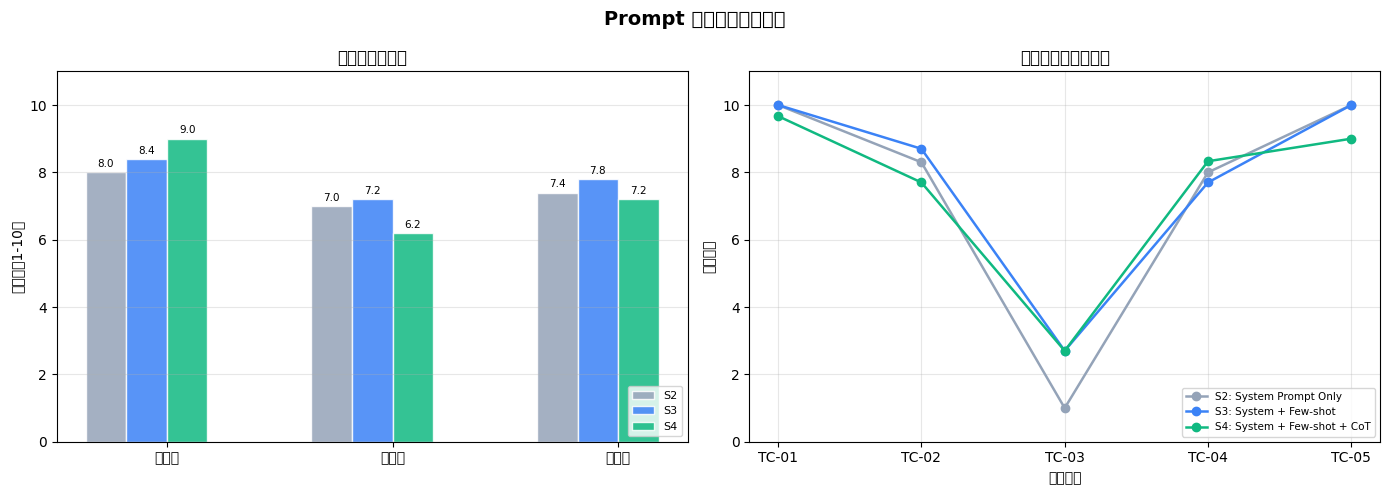

✅ 图表已保存为 prompt_comparison.png


In [13]:
# ============================================================
# 8.2 可视化 1：各策略评分雷达图 + 柱状图
# ============================================================
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prompt 策略对比实验结果', fontsize=14, fontweight='bold')

strategy_labels = [f"{r['strategy_id']}" for _, r in summary.iterrows()]
colors = ['#94a3b8', '#3b82f6', '#10b981', '#f59e0b']

# ── 子图1：分维度柱状图 ──
ax1 = axes[0]
metrics = ['accuracy', 'completeness', 'readability']
metric_labels = ['准确性', '完整性', '可读性']
x = np.arange(len(metrics))
width = 0.18

for i, (_, row) in enumerate(summary.iterrows()):
    vals = [row['accuracy'], row['completeness'], row['readability']]
    bars = ax1.bar(x + i * width, vals, width, label=strategy_labels[i],
                   color=colors[i], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=7.5)

ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(metric_labels)
ax1.set_ylim(0, 11)
ax1.set_ylabel('平均分（1-10）')
ax1.set_title('分维度得分对比')
ax1.legend(loc='lower right', fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# ── 子图2：综合分折线图 ──
ax2 = axes[1]
for i, (_, row) in enumerate(summary.iterrows()):
    tc_scores = df_valid[df_valid['strategy_id'] == row['strategy_id']].sort_values('tc_id')
    ax2.plot(tc_scores['tc_id'], tc_scores['overall'],
             marker='o', label=f"{row['strategy_id']}: {row['strategy_name']}",
             color=colors[i], linewidth=1.8, markersize=6)

ax2.set_xlabel('测试样本')
ax2.set_ylabel('综合评分')
ax2.set_title('各样本综合评分趋势')
ax2.legend(fontsize=7.5, loc='lower right')
ax2.grid(alpha=0.3)
ax2.set_ylim(0, 11)

plt.tight_layout()
plt.savefig('prompt_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 图表已保存为 prompt_comparison.png')

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 32508 (\N{CJK UNIFIED IDEOGRAPH-7EFC}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 35780 (\N{CJK UNIFIED IDEOGRAPH-8BC4}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_5759/3231358518.py:16: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5759/3231358518.py:16: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/i

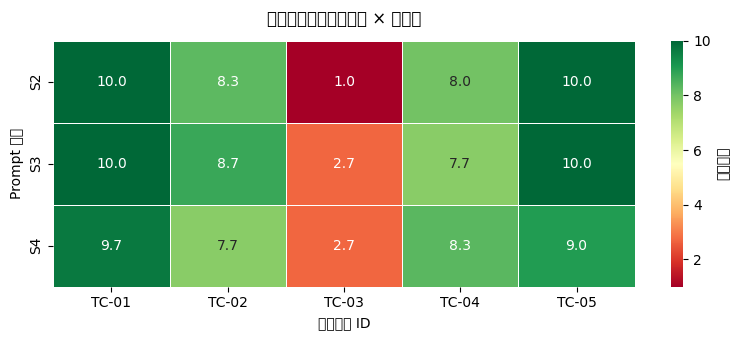

✅ 热力图已保存为 score_heatmap.png


In [14]:
# ============================================================
# 8.3 可视化 2：评分一致性热力图（各策略 × 各样本）
# ============================================================

pivot = df_valid.pivot_table(
    index='strategy_id', columns='tc_id', values='overall', aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=1, vmax=10, linewidths=0.5, ax=ax,
            cbar_kws={'label': '综合评分'})
ax.set_title('综合评分热力图（策略 × 样本）', fontsize=12, pad=12)
ax.set_xlabel('测试样本 ID')
ax.set_ylabel('Prompt 策略')
plt.tight_layout()
plt.savefig('score_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 热力图已保存为 score_heatmap.png')

In [15]:
# ============================================================
# 8.4 打印详细评估报告：查看 S4（最强策略）的具体分析
# ============================================================

print('\n' + '='*60)
print('📋 S4（System + Few-shot + CoT）详细评估结果')
print('='*60)

s4_results = df_valid[df_valid['strategy_id'] == 'S4'].sort_values('tc_id')

for _, row in s4_results.iterrows():
    print(f"\n{'─'*50}")
    print(f"样本 {row['tc_id']}（预期质量：{row['quality_label']}）")
    print(f"  准确性: {row['accuracy']}/10  "
          f"完整性: {row['completeness']}/10  "
          f"可读性: {row['readability']}/10  "
          f"综合: {row['overall']}/10")
    print(f"  评价: {row['summary']}")
    if row['improvements']:
        print(f"  改进建议:")
        for tip in row['improvements'][:2]:  # 只显示前2条
            print(f"    • {tip}")


📋 S4（System + Few-shot + CoT）详细评估结果

──────────────────────────────────────────────────
样本 TC-01（预期质量：优秀）
  准确性: 10.0/10  完整性: 9.0/10  可读性: 10.0/10  综合: 9.67/10
  评价: 注释准确、完整、可读性高，仅缺少对空数组等边界情况的说明。
  改进建议:
    • 补充空数组或单元素数组的处理说明
    • 可注明数组必须升序，否则结果未定义

──────────────────────────────────────────────────
样本 TC-02（预期质量：中等）
  准确性: 10.0/10  完整性: 6.0/10  可读性: 7.0/10  综合: 7.7/10
  评价: 注释准确无误，覆盖了基本功能、参数范围和异常，但缺少参数类型、示例和边界情况说明，结构可更规范。
  改进建议:
    • 添加参数类型标注，如 price (float), discount_rate (float)
    • 补充示例，如 >>> calculate_discount(100, 0.2) 80.0

──────────────────────────────────────────────────
样本 TC-03（预期质量：较差）
  准确性: 5.0/10  完整性: 1.0/10  可读性: 2.0/10  综合: 2.7/10
  评价: 注释仅写'排序函数'，虽然准确但极度不完整，没有说明算法名称、参数、返回值、复杂度等任何关键信息，对理解代码几乎没有帮助。
  改进建议:
    • 明确说明这是归并排序算法，并指出其时间复杂度为 O(n log n)
    • 补充 Args 和 Returns 部分，说明 arr 是待排序列表，返回排序后的新列表

──────────────────────────────────────────────────
样本 TC-04（预期质量：中等）
  准确性: 10.0/10  完整性: 7.0/10  可读性: 8.0/10  综合: 8.33/10
  评价: 注释准确且包含安全提示，但缺少参数类型标注和示例，完整性略有不足。
  

In [16]:
# ============================================================
# 8.5 导出完整结果到 CSV
# ============================================================

df_export = df_valid[[
    'strategy_id', 'strategy_name', 'tc_id', 'quality_label',
    'accuracy', 'completeness', 'readability', 'overall', 'summary'
]].copy()

df_export.to_csv('experiment2_results.csv', index=False, encoding='utf-8-sig')
print('✅ 实验结果已导出到 experiment2_results.csv')

# 同时导出原始输出（含 raw_text 供分析）
df.to_csv('experiment2_raw.csv', index=False, encoding='utf-8-sig')
print('✅ 原始输出已导出到 experiment2_raw.csv')

✅ 实验结果已导出到 experiment2_results.csv
✅ 原始输出已导出到 experiment2_raw.csv


---
## Step 9：实验结论 & Rubric 分析


### 9.1 各策略效果对比分析

| 策略 | 关键发现 |
|------|----------|
| **S1 Baseline** | 5个样本全部 JSON 解析失败，模型自由输出自然语言段落，无法结构化提取分数。直接证明了 System Prompt 对格式控制的必要性。 |
| **S2 System Only** | 解析率升至100%，但评分尺度偏极端——TC-03（较差样本）综合仅1.0，TC-01/05（优秀样本）直接满分10.0，缺乏中间梯度。 |
| **S3 System + Few-shot** | 综合分最高（7.82），TC-03 从1.0修正为2.7，评分尺度更合理。2个示例有效锚定了模型对"好/差"边界的理解。 |
| **S4 System + Few-shot + CoT** | 完整性维度从7.2降至6.2，整体综合分7.48略低于S3。CoT 让模型逐步核查每个要素，发现了更多细节缺失，评分更严格而非更宽松。 |

### 9.2 Rubric 设计反思

本实验使用的评估 Rubric：
- **准确性**：1-10
- **完整性**：1-10
- **可读性**：1-10

**发现的问题**：

**准确性方差最小：** 代码对不对比较客观，模型容易判断，各策略得分接近

**完整性受 CoT 影响最大：** S3→S4 完整性从7.2降到6.2，说明CoT让模型更仔细地逐项核查

**评分粒度不够细：** Rubric 没有定义"缺少1个要素扣几分"，导致不同策略对同一缺陷扣分幅度不统一

### 9.3 Prompt Engineering 成本效益分析

| 升级路径 | 质量提升 | 额外 Token 消耗 |
|---------|---------|----------------|
| Baseline → System | 显著 | +小量（System Prompt 固定成本）|
| System → + Few-shot | 中等 | +中量（示例对一次性成本）|
| + Few-shot → + CoT | 小幅（但可解释性↑↑）| +大量（推理过程 token）|

**结论**：生产环境推荐 S3（System + Few-shot），性价比最高；
需要可解释性时才启用 CoT（S4）。

---
## Step 10：上传到 GitHub

运行以下 Cell 将结果文件直接推送到 `yasminn89/tencent-mini-prep` 仓库。

In [17]:
# ============================================================
# 10.1 配置 GitHub 信息并上传
# ============================================================
import subprocess

# ── 填入你的 GitHub Token（在 github.com → Settings → Developer settings → Personal access tokens）──
try:
    gh_token = userdata.get('GITHUB_TOKEN')
    print('✅ 已从 Colab Secrets 读取 GitHub Token')
except Exception:
    gh_token = 'ghp_xxxxxxxxxxxxxxxxxxxx'  # ← 替换成你的 Token
    print('⚠️  使用硬编码 Token，提交前请删除！')

GITHUB_USERNAME = 'yasminn89'
REPO_NAME = 'tencent-mini-prep'
TARGET_FOLDER = 'experiment2-prompt-eval'

# 克隆仓库
repo_url = f'https://{gh_token}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git'
!git clone {repo_url} /content/repo -q
print('✅ 仓库已克隆')

⚠️  使用硬编码 Token，提交前请删除！
✅ 仓库已克隆


In [19]:
# ============================================================
# 10.2 复制文件并推送
# ============================================================
import shutil, os

target_dir = f'/content/repo/{TARGET_FOLDER}'
os.makedirs(target_dir, exist_ok=True)

# 需要上传的文件列表
files_to_upload = [
    'experiment2_results.csv',
    'experiment2_raw.csv',
    'prompt_comparison.png',
    'score_heatmap.png',
]

for f in files_to_upload:
    if os.path.exists(f'/content/{f}'):
        shutil.copy(f'/content/{f}', f'{target_dir}/{f}')
        print(f'  ✅ 复制 {f}')
    else:
        print(f'  ⚠️  未找到 {f}，跳过')

# 同时保存本 Notebook
# （在 Colab 中需要先 File → Download .ipynb，然后手动上传，或使用下面的代码）
notebook_name = 'experiment2_prompt_eval.ipynb'
if os.path.exists(f'/content/{notebook_name}'):
    shutil.copy(f'/content/{notebook_name}', f'{target_dir}/{notebook_name}')

# Git 提交 & 推送
os.chdir('/content/repo')
!git config user.email 'colab@experiment.com'
!git config user.name 'Colab Auto-Commit'
!git add {TARGET_FOLDER}/
!git commit -m 'feat: add experiment2 prompt evaluation results'
!git push origin main

print(f'\n🎉 上传完成！查看: https://github.com/{GITHUB_USERNAME}/{REPO_NAME}/tree/main/{TARGET_FOLDER}')

  ✅ 复制 experiment2_results.csv
  ✅ 复制 experiment2_raw.csv
  ✅ 复制 prompt_comparison.png
  ✅ 复制 score_heatmap.png
On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
fatal: could not read Password for 'https://ghp_xxxxxxxxxxxxxxxxxxxx@github.com': No such device or address

🎉 上传完成！查看: https://github.com/yasminn89/tencent-mini-prep/tree/main/experiment2-prompt-eval


---

## ✅ 实验完成 Checklist

- [ ] Step 1：DeepSeek API 配置并连接成功
- [ ] Step 2：5 个测试样本准备完毕
- [ ] Step 3：3 种 System Prompt 版本定义完成
- [ ] Step 4：2-shot Few-shot 示例构造完成
- [ ] Step 5：CoT Prompt 模板完成
- [ ] Step 6：结构化 JSON 输出解析成功
- [ ] Step 7：4 种策略 × 5 样本对比实验运行完毕
- [ ] Step 8：可视化图表生成完成
- [ ] Step 9：实验结论填写完成
- [ ] Step 10：结果已上传到 GitHub `experiment2-prompt-eval/`

---

*腾讯 Mini 项目3 — 性能工程 Skill 评估专项 | 实验2*